# Optimisation

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

# Crucial pour l'interactivité dans le notebook
%matplotlib inline


In [2]:
import itertools

import matplotlib.pyplot as plt

from nn import *

In [3]:
model = Linear(1, 1)

In [4]:
W, b = model.parameters()

In [5]:
X = np.random.uniform(-1., 1., (10, 1))
Y = 2 * X - 1 + np.random.normal(0., 0.5, (10, 1))
X = Tensor(X)
Y = Tensor(Y)

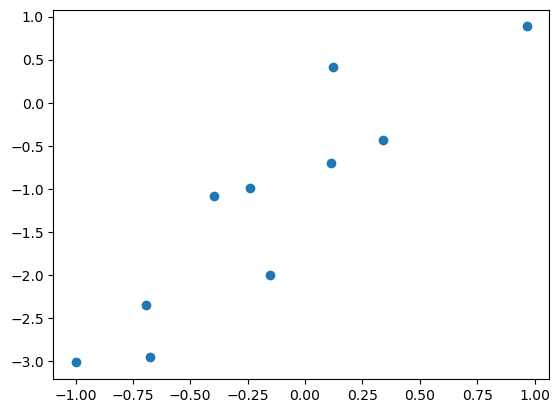

In [6]:
plt.scatter(X, Y);

In [7]:
def plot_error_function(model, X, Y, batch_size, m=50, ax=None):
    n = X.shape[0]
    W, b = model.parameters()
    combinations = list(itertools.combinations(range(n), batch_size))
    j = np.random.choice(range(len(combinations)))
    batch = list(combinations[j])
    Z1, Z2 = np.meshgrid(np.linspace(-10., 10., m), np.linspace(-10., 10., m))
    Z = np.stack((Z1.ravel(), Z2.ravel())).T
    X_ = X[batch, :]
    Y_ = Y[batch, :]
    e_arr = []
    for z in Z:
        W.copy(z[0])
        b.copy(z[1])
        Yhat = model.forward(X_)
        e = ((Y_ - Yhat)**2).mean()
        e_arr.append(e)
    e_arr = np.array(e_arr).reshape((m, m))
    if ax is None:
        plt.contourf(Z1, Z2, log(e_arr + 1e-16), levels=32, cmap="cividis")
    else:
        ax.contourf(Z1, Z2, log(e_arr + 1e-16), levels=32, cmap="cividis")

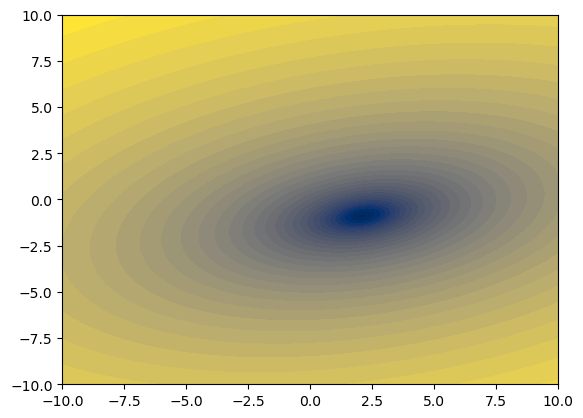

In [8]:
plot_error_function(model, X, Y, batch_size=10, m=100)

In [28]:
class OptimDemo:
    def __init__(self, n_points=10):
        self.n = n_points
        self.history = []
        self.current_batch_indices = []
        self.last_grad = None
        
        # --- LA ZONE DE DESSIN FIXE (Layout robuste) ---
        # On définit une hauteur fixe pour éviter que la page ne saute
        self.out = widgets.Output(layout=widgets.Layout(
            height='450px', 
            border='1px solid #dddddd',
            overflow_y='hidden' # On interdit le scroll interne
        ))
        
        # --- LES OUTILS ---
        self.slider_batch = widgets.IntSlider(value=1, min=1, max=self.n, description='Batch Size:')
        self.btn_step = widgets.Button(description='Step 🛠️', button_style='info')
        self.btn_init = widgets.Button(description='Reset 🚿', button_style='danger')
        
        self.btn_step.on_click(self.step)
        self.btn_init.on_click(self.reset_all)
        self.slider_batch.observe(self.update_plot, names='value')

        self.slider_learning_rate = widgets.FloatSlider(value=0.1, min=0.001, max=1.0, step=0.001, description='Learning rate:')
        self.slider_momentum = widgets.FloatSlider(value=0.0, min=0.0, max=0.99, step=0.01, description=r'$\beta_1$:')
        self.slider_momentum_sq = widgets.FloatSlider(value=0.0, min=0.0, max=0.999, step=0.001, description=r'$\beta_2$:')
        
        
        # --- L'ASSEMBLAGE ---
        self.ui = widgets.VBox([
            widgets.HBox([self.slider_batch, self.slider_learning_rate, self.slider_momentum, self.slider_momentum_sq]),
            widgets.HBox([self.btn_step, self.btn_init]),
            self.out 
        ])
        
        display(self.ui)
        self.reset_all()

    def reset_all(self, b=None):
        # Données
        x_raw = np.random.uniform(-1., 1., (self.n, 1))
        y_raw = 2 * x_raw - 1 + np.random.normal(0., 0.3, (self.n, 1))
        self.X = Tensor(x_raw)
        self.Y = Tensor(y_raw)
        
        # Modèle
        self.model = Linear(1, 1)
        self.W, self.bias = self.model.parameters()
        self.W.copy(np.array([[8.0]]))
        self.bias.copy(np.array([[-8.0]]))
        
        self.loss_fn = MSELoss()
        beta1 = self.slider_momentum.value
        beta2 = self.slider_momentum_sq.value
        alpha = self.slider_learning_rate.value
        if beta1 <= 1e-8 and beta2 <= 1e-8:
            self.optimizer = SGD(self.model.parameters(), learning_rate=alpha)
        elif beta1 >= 1e-8 and beta2 <= 1e-8:
            self.optimizer = SGDWithMomentum(self.model.parameters(), learning_rate=alpha, beta1=beta1)
        elif beta1 <= 1e-8 and beta2 >= 1e-8:
            self.optimizer = RMSprop(self.model.parameters(), learning_rate=alpha, beta2=beta2)
        else:
            self.optimizer = Adam(self.model.parameters(), learning_rate=alpha, beta1=beta1, beta2=beta2)
        
        self.history = [(self.W.item(), self.bias.item())]
        self.last_grad = None
        self.current_batch_indices = []
        self.update_plot()

    def fast_mse_surface(self, X_batch, Y_batch, w_range, b_range):
        W_grid, B_grid = np.meshgrid(w_range, b_range)        
        W_flat = W_grid[:, :, np.newaxis]
        B_flat = B_grid[:, :, np.newaxis]
        predictions = W_flat * X_batch.data.T + B_flat
        errors = (Y_batch.data.T - predictions)**2
        return errors.mean(axis=2)

    def step(self, b=None):
        batch_size = self.slider_batch.value
        indices = np.random.choice(range(self.n), batch_size, replace=False)
        self.current_batch_indices = indices
        
        X_b = self.X[indices, :]
        Y_b = self.Y[indices, :]
        
        # Forward/Backward
        pred = self.model.forward(X_b)
        loss = self.loss_fn.forward(pred, Y_b)
        grad_out = self.loss_fn.backward()
        self.model.backward(grad_out)
        
        self.last_grad = (self.W.grad.item(), self.bias.grad.item())
        self.optimizer.step()
        self.history.append((self.W.item(), self.bias.item()))
        self.update_plot()

    def update_plot(self, change=None):
        with self.out:
            clear_output(wait=True)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
            
            m = 50
            w_range = np.linspace(-10., 10., m)
            b_range = np.linspace(-10., 10., m)
            W_grid, B_grid = np.meshgrid(w_range, b_range)
            
            path = np.array(self.history)
            
            # --- 1. TRACÉ DE GAUCHE : SURFACE GLOBALE ---
            # On montre toujours la position ACTUELLE (après le step)
            full_mse = self.fast_mse_surface(self.X, self.Y, w_range, b_range)
            ax1.contourf(W_grid, B_grid, full_mse, levels=30, cmap="Greys")
            
            ax1.plot(path[:, 0], path[:, 1], 'r-o', markersize=3, alpha=0.6)
            ax1.plot(path[-1, 0], path[-1, 1], 'ro', markersize=8, label="Position actuelle")
            ax1.set_title("Surface d'erreur TOTALE\n(Point Rouge = Après optimisation)")
            ax1.legend()

            # --- 2. TRACÉ DE DROITE : MINI-BATCH ---
            # On montre la position AVANT le dernier step pour le point et le gradient
            batch_size = self.slider_batch.value
            indices = self.current_batch_indices if len(self.current_batch_indices) > 0 else list(range(batch_size))
            mini_mse = self.fast_mse_surface(self.X[indices, :], self.Y[indices, :], w_range, b_range)
            ax2.contourf(W_grid, B_grid, mini_mse, levels=30, cmap="Greys")
            
            # Logique d'affichage du point "Avant Step"
            if len(path) > 1 and self.last_grad is not None:
                # On affiche le point d'où l'on vient
                point_avant = path[-2]
                origin_w, origin_b = point_avant[0], point_avant[1]
                
                # Le vecteur gradient part de ce point
                # On multiplie par le learning rate pour montrer l'amplitude réelle du saut
                lr = 1 #self.optimizer.learning_rate
                ax2.arrow(origin_w, origin_b, -self.last_grad[0] * lr, -self.last_grad[1] * lr, 
                         head_width=0.4, head_length=0.5, fc='red', ec='red', length_includes_head=True)
                
                ax2.plot(origin_w, origin_b, 'co', markersize=8, markeredgecolor='k', label="Point de calcul")
            else:
                # Au tout début, on affiche juste le point actuel
                ax2.plot(path[-1, 0], path[-1, 1], 'co', markersize=8, markeredgecolor='k')
            
            ax2.set_title(f"Surface perçue par le Mini-Batch (n={batch_size})\n(Point Bleu = Avant optimisation)")
            if len(path) > 1: ax2.legend()
            ax1.set_xlim((-10., 10.))
            ax1.set_ylim((-10., 10.))
            ax2.set_xlim((-10., 10.))
            ax2.set_ylim((-10., 10.))
            plt.show()

# On lance la machine
demo = OptimDemo(n_points=10)

In [10]:
class OptimDemo:
    def __init__(self, n_points=10):
        self.n = n_points
        self.history = []
        self.current_batch_indices = []
        self.last_grad = None
        
        # --- LA ZONE DE DESSIN FIXE (Layout robuste) ---
        # On définit une hauteur fixe pour éviter que la page ne saute
        self.out = widgets.Output(layout=widgets.Layout(
            height='450px', 
            border='1px solid #dddddd',
            overflow_y='hidden' # On interdit le scroll interne
        ))
        
        # --- LES OUTILS ---
        self.slider_batch = widgets.IntSlider(value=1, min=1, max=self.n, description='Batch Size:')
        self.btn_step = widgets.Button(description='Step 🛠️', button_style='info')
        self.btn_init = widgets.Button(description='Reset 🚿', button_style='danger')
        
        self.btn_step.on_click(self.step)
        self.btn_init.on_click(self.reset_all)
        self.slider_batch.observe(self.update_plot, names='value')

        self.slider_learning_rate = widgets.FloatSlider(value=0.1, min=0.001, max=1.0, step=0.001, description='Learning rate:')
        self.slider_momentum = widgets.FloatSlider(value=0.0, min=0.0, max=0.99, step=0.01, description=r'$\beta_1$:')
        self.slider_momentum_sq = widgets.FloatSlider(value=0.0, min=0.0, max=0.999, step=0.001, description=r'$\beta_2$:')
        
        
        # --- L'ASSEMBLAGE ---
        self.ui = widgets.VBox([
            widgets.HBox([self.slider_batch, self.slider_learning_rate, self.slider_momentum, self.slider_momentum_sq]),
            widgets.HBox([self.btn_step, self.btn_init]),
            self.out 
        ])
        
        display(self.ui)
        self.reset_all()

    def reset_all(self, b=None):
        # Données
        x_raw = np.random.uniform(-1., 1., (self.n, 1))
        y_raw = 4 * x_raw + np.random.normal(0., 0.3, (self.n, 1))
        self.X = Tensor(x_raw)
        self.Y = Tensor(y_raw)
        
        # Modèle
        self.model = Sequential([Linear(1, 1, bias=False), Linear(1, 1, bias=False)])
        self.W1, self.W2 = self.model.parameters()
        self.W1.copy(np.array([[np.random.uniform(-2., 2.)]]))
        self.W2.copy(np.array([[np.random.uniform(-2., 2.)]]))
        
        self.loss_fn = MSELoss()
        beta1 = self.slider_momentum.value
        beta2 = self.slider_momentum_sq.value
        alpha = self.slider_learning_rate.value
        if beta1 <= 1e-8 and beta2 <= 1e-8:
            self.optimizer = SGD(self.model.parameters(), learning_rate=alpha)
        elif beta1 >= 1e-8 and beta2 <= 1e-8:
            self.optimizer = SGDWithMomentum(self.model.parameters(), learning_rate=alpha, beta1=beta1)
        elif beta1 <= 1e-8 and beta2 >= 1e-8:
            self.optimizer = RMSprop(self.model.parameters(), learning_rate=alpha, beta2=beta2)
        else:
            self.optimizer = Adam(self.model.parameters(), learning_rate=alpha, beta1=beta1, beta2=beta2)
        
        self.history = [(self.W1.item(), self.W2.item())]
        self.last_grad = None
        self.current_batch_indices = []
        self.update_plot()

    def fast_mse_surface(self, X_batch, Y_batch, w_range, b_range):
        W1_grid, W2_grid = np.meshgrid(w_range, b_range)
        W1_flat = W1_grid[:, :, np.newaxis]
        W2_flat = W2_grid[:, :, np.newaxis]
        predictions = W2_flat * W1_flat * X_batch.data.T
        errors = (Y_batch.data.T - predictions)**2
        return errors.mean(axis=2)

    def step(self, b=None):
        batch_size = self.slider_batch.value
        indices = np.random.choice(range(self.n), batch_size, replace=False)
        self.current_batch_indices = indices
        
        X_b = self.X[indices, :]
        Y_b = self.Y[indices, :]
        
        # Forward/Backward
        pred = self.model.forward(X_b)
        loss = self.loss_fn.forward(pred, Y_b)
        grad_out = self.loss_fn.backward()
        self.model.backward(grad_out)
        
        self.last_grad = (self.W1.grad.item(), self.W2.grad.item())
        self.optimizer.step()
        self.history.append((self.W1.item(), self.W2.item()))
        self.update_plot()

    def update_plot(self, change=None):
        with self.out:
            clear_output(wait=True)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
            
            m = 50
            w_range = np.linspace(-2., 2., m)
            b_range = np.linspace(-2., 2., m)
            W_grid, B_grid = np.meshgrid(w_range, b_range)
            
            path = np.array(self.history)
            
            # --- 1. TRACÉ DE GAUCHE : SURFACE GLOBALE ---
            # On montre toujours la position ACTUELLE (après le step)
            full_mse = self.fast_mse_surface(self.X, self.Y, w_range, b_range)
            ax1.contourf(W_grid, B_grid, full_mse, levels=30, cmap="cividis")
            
            ax1.plot(path[:, 0], path[:, 1], 'w-o', markersize=3, alpha=0.6)
            ax1.plot(path[-1, 0], path[-1, 1], 'ro', markersize=8, label="Position actuelle")
            ax1.set_title("Surface d'erreur TOTALE\n(Point Rouge = Après optimisation)")
            ax1.legend()

            # --- 2. TRACÉ DE DROITE : MINI-BATCH ---
            # On montre la position AVANT le dernier step pour le point et le gradient
            batch_size = self.slider_batch.value
            indices = self.current_batch_indices if len(self.current_batch_indices) > 0 else list(range(batch_size))
            mini_mse = self.fast_mse_surface(self.X[indices, :], self.Y[indices, :], w_range, b_range)
            ax2.contourf(W_grid, B_grid, mini_mse, levels=30, cmap="cividis")
            
            # Logique d'affichage du point "Avant Step"
            if len(path) > 1 and self.last_grad is not None:
                # On affiche le point d'où l'on vient
                point_avant = path[-2]
                origin_w, origin_b = point_avant[0], point_avant[1]
                
                # Le vecteur gradient part de ce point
                # On multiplie par le learning rate pour montrer l'amplitude réelle du saut
                lr = 1 #self.optimizer.learning_rate
                ax2.arrow(origin_w, origin_b, -self.last_grad[0] * lr, -self.last_grad[1] * lr, 
                         head_width=0.4/5, head_length=0.5/5, fc='white', ec='white', length_includes_head=True)
                
                ax2.plot(origin_w, origin_b, 'co', markersize=8, markeredgecolor='k', label="Point de calcul")
            else:
                # Au tout début, on affiche juste le point actuel
                ax2.plot(path[-1, 0], path[-1, 1], 'co', markersize=8, markeredgecolor='k')
            
            ax2.set_title(f"Surface perçue par le Mini-Batch (n={batch_size})\n(Point Bleu = Avant optimisation)")
            if len(path) > 1: ax2.legend()
            ax1.set_xlim((-2., 2.))
            ax1.set_ylim((-2., 2.))
            ax2.set_xlim((-2., 2.))
            ax2.set_ylim((-2., 2.))
            plt.show()

# On lance la machine
demo = OptimDemo(n_points=10)

In [11]:
demo.W1, demo.W2

(array([[-0.26670592]]), array([[-0.29313442]]))

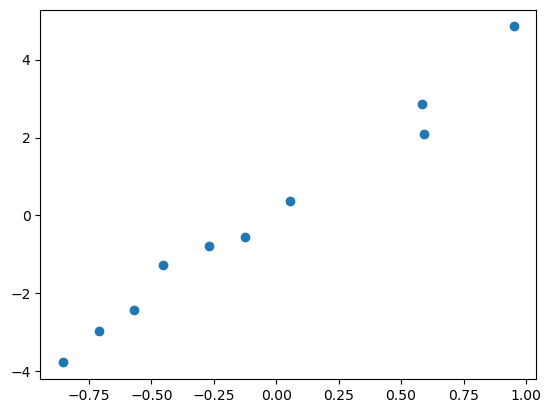

In [12]:
plt.scatter(demo.X, demo.Y);

## Exponential weighted average

In [13]:
np.random.seed(13)

In [14]:
n = 100
array = np.random.normal(0., 1., (n, 1)).cumsum()
array = array - array.mean()

In [15]:
def compute_ewa(x, beta1=0.9, bias_correction=True):
    n = x.shape[0]
    ewa = np.zeros_like(array)
    v = 0
    for i in range(n):
        v = beta1 * v + (1 - beta1) * array[i]
        ewa[i] = v
        if bias_correction:
            ewa[i] /= 1 - beta1**(i+1)
    return ewa

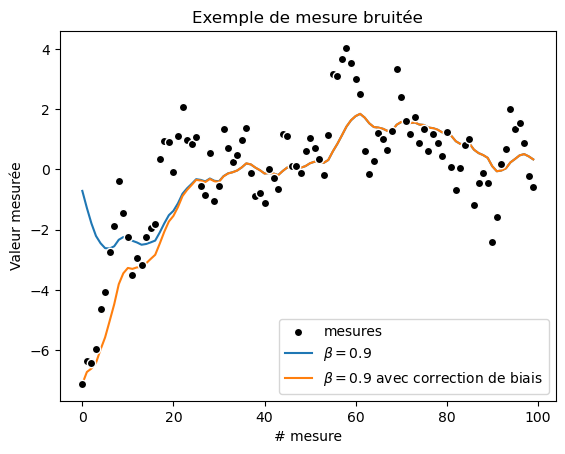

In [16]:
plt.scatter(range(n), array, edgecolor='w', color="k", label="mesures", zorder=10);
plt.xlabel("# mesure")
plt.ylabel("Valeur mesurée")
# plt.plot(compute_ewa(array, beta1=0., bias_correction=False), label=r"$\beta = 0$");
# plt.plot(compute_ewa(array, beta1=1., bias_correction=False), label=r"$\beta = 1$");
# plt.plot(compute_ewa(array, beta1=0.5, bias_correction=False), label=r"$\beta = 0.5$");
plt.plot(compute_ewa(array, beta1=0.9, bias_correction=False), label=r"$\beta = 0.9$");
# plt.plot(compute_ewa(array, beta1=0.5, bias_correction=True), label=r"$\beta = 0.5$ avec correction de biais");
plt.plot(compute_ewa(array, beta1=0.9, bias_correction=True), label=r"$\beta = 0.9$ avec correction de biais");
plt.legend();
plt.title("Exemple de mesure bruitée");

In [17]:
beta1 = 0.9
coeff = []
for i in range(100):
    coeff.append((1 - beta1) * beta1**(i-1))

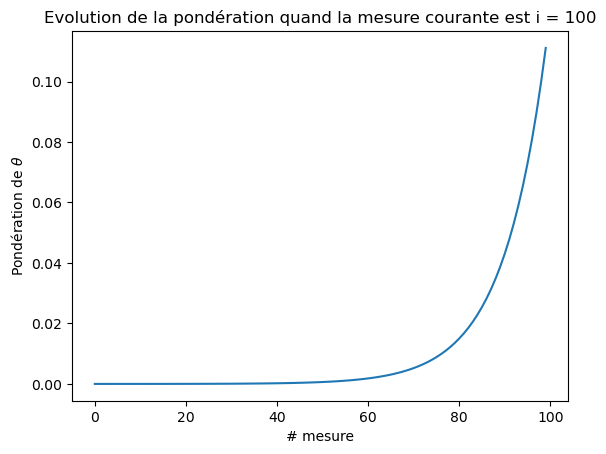

In [18]:
plt.plot(coeff[::-1]);
plt.xlabel("# mesure")
plt.ylabel(r"Pondération de $\theta$");
plt.title("Evolution de la pondération quand la mesure courante est i = 100");

## MSE vs BCE

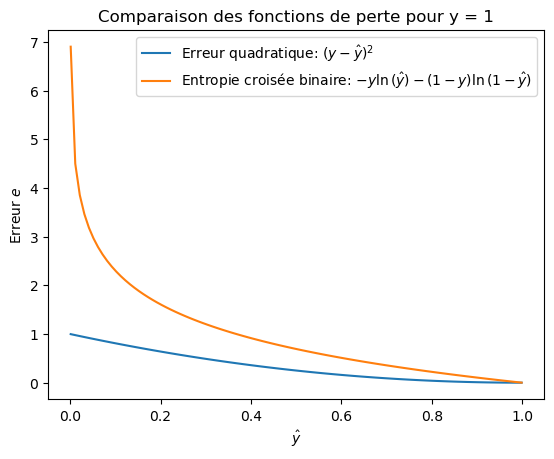

In [19]:
y = 1
yhat = np.linspace(0.001, 0.999, 100)
se = (y - yhat)**2
bce = - y * np.log(yhat) - (1 - y) * np.log(1 - yhat)
plt.plot(yhat, se, label=r"Erreur quadratique: $(y - \hat{y})^2$");
plt.plot(yhat, bce, label=r"Entropie croisée binaire: $- y \ln{(\hat{y})} - (1 - y) \ln{(1 - \hat{y})}$");
plt.ylabel(r"Erreur $e$")
plt.xlabel(r"$\hat{y}$")
plt.title("Comparaison des fonctions de perte pour y = 1")
plt.legend();

## Initialisation

In [20]:
# Configuration du réseau profond imaginaire
num_layers = 3
layer_size = 1000
n_observations = 2000

# Génération d'une entrée aléatoire saine (centrée, variance 1)
X_init = np.random.randn(n_observations, layer_size)

def simulate_forward(init_mode="naive", activation="tanh"):
    X = X_init.copy()
    layer_activations = [X]
    
    # Fonctions d'activation du framework light
    def tanh(z): 
        return np.tanh(z)
    def relu(z): 
        return np.maximum(0, z)
    def logistic(z):
        return 1 / (1 + np.exp(-z))
    if activation == "tanh":
        act_func = tanh
    elif activation == "relu":
        act_func = relu
    else:
        act_func = logistic

    for l in range(num_layers):
        n_in = layer_size
        n_out = layer_size

        # Calcul du gain pour les initialisations Xavier
        if activation == "tanh":
            gain = 5 / 3
        elif activation == "relu":
            gain = np.sqrt(2)
        elif activation == "logistic":
            gain = 1.0
        
        # Choix du mode d'initialisation
        if init_mode == "naive_normal":
            # loi normale standard
            sigma = 1.0
            W = np.random.randn(n_in, n_out) * sigma
        elif init_mode == "naive_uniform":
            # loi uniforme de variance unitaire
            W = np.random.uniform(-np.sqrt(3), np.sqrt(3), (n_in, n_out))
        elif init_mode == "xavier_normal":
            sigma = gain * np.sqrt(2.0 / (n_in + n_out))
            W = np.random.randn(n_in, n_out) * sigma
        elif init_mode == "xavier_uniform":
            W = np.random.uniform(-gain * np.sqrt(6 / (n_in + n_out)), gain * np.sqrt(6 / (n_in + n_out)), (n_in, n_out))
        elif init_mode == "kaiming_normal":
            sigma = np.sqrt(2.0 / n_in)
            W = np.random.randn(n_in, n_out) * sigma
        elif init_mode == "kaiming_uniform":
            W = np.random.uniform(-np.sqrt(6 / n_in), np.sqrt(6 / n_in), (n_in, n_out))
        b = np.zeros((1, n_out))
        
        # Passe avant de la couche
        Z = X @ W + b
        X = act_func(Z)
        layer_activations.append(X)
        
    return layer_activations

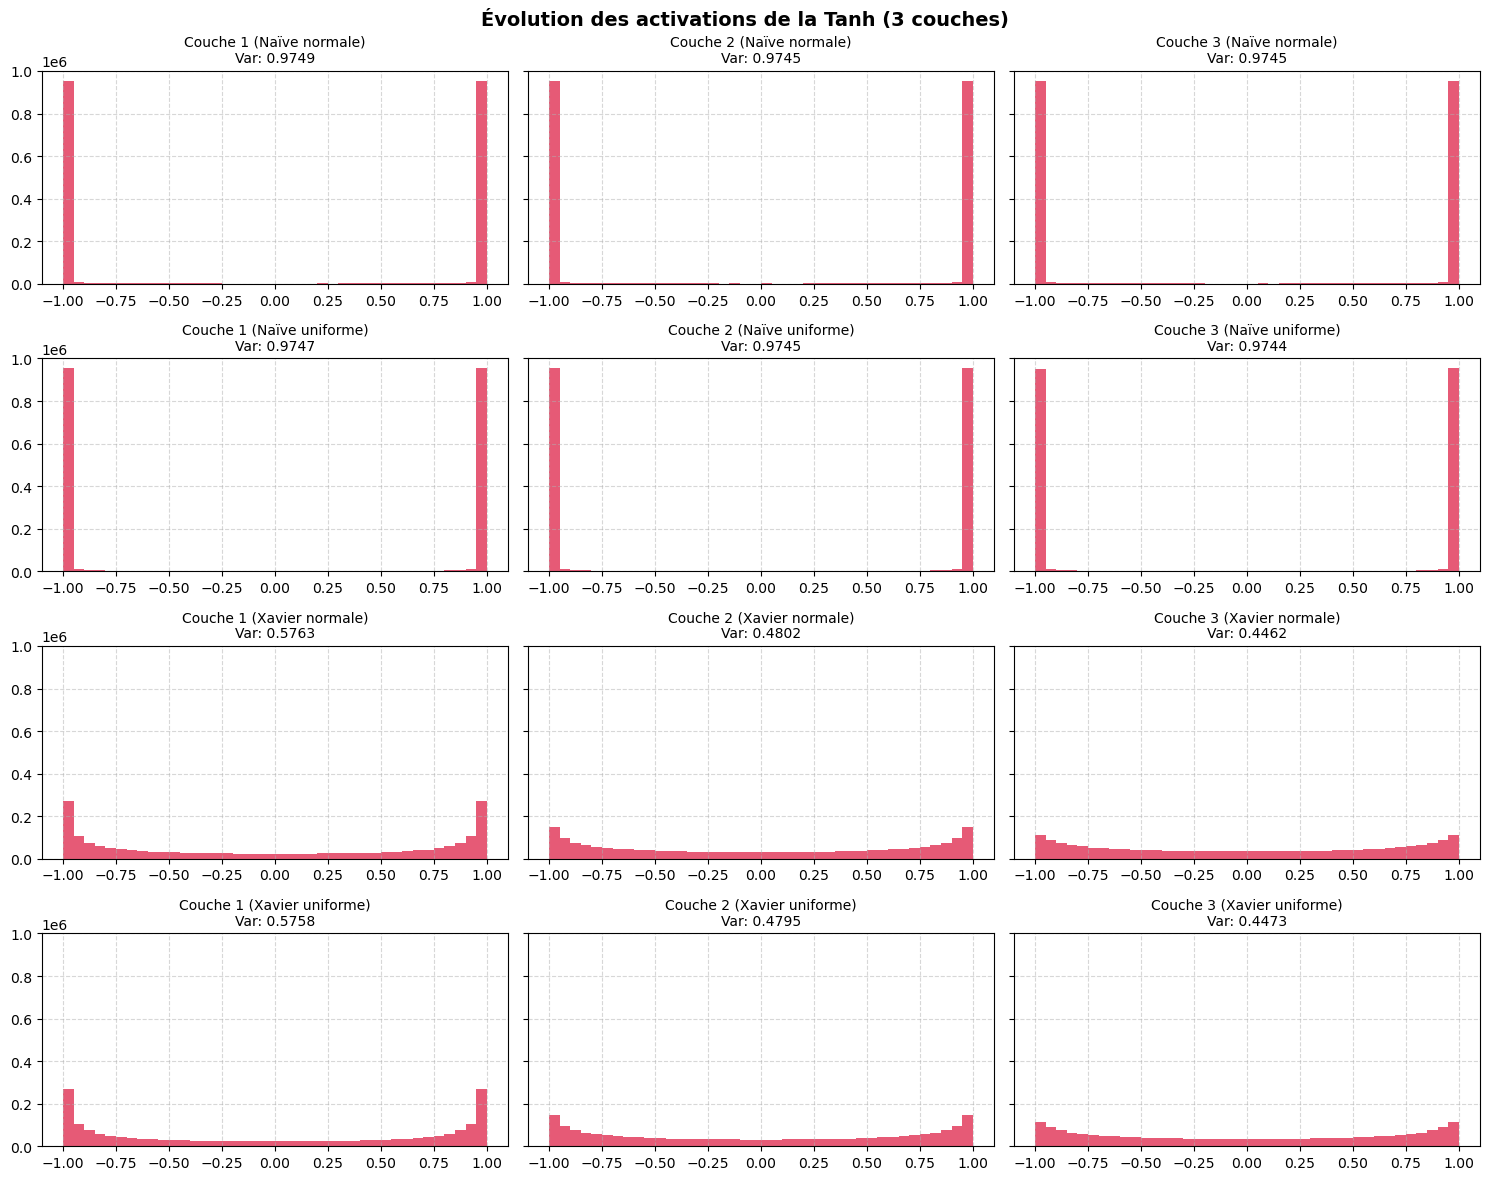

In [21]:
# --- Simulation 1 : Tanh avec Initialisation Naïve vs Xavier ---
activation = "tanh"
activations_naive_normal = simulate_forward(init_mode="naive_normal", activation=activation)
activations_naive_uniform = simulate_forward(init_mode="naive_uniform", activation=activation)
activations_better_normal = simulate_forward(init_mode="xavier_normal", activation=activation)
activations_better_uniform = simulate_forward(init_mode="xavier_uniform", activation=activation)

fig, axes = plt.subplots(4, num_layers, figsize=(15, 12), sharey=True)
fig.suptitle("Évolution des activations de la Tanh (3 couches)", fontsize=14, fontweight='bold')

for i in range(num_layers):
    # Ligne 1 : Init Naïve normale
    axes[0, i].hist(activations_naive_normal[i+1].flatten(), bins=40, range=(-1, 1), color='crimson', alpha=0.7)
    axes[0, i].set_title(f"Couche {i+1} (Naïve normale)\nVar: {np.var(activations_naive_normal[i+1]):.4f}", fontsize=10)
    axes[0, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 2 : Init Naïve uniforme
    axes[1, i].hist(activations_naive_uniform[i+1].flatten(), bins=40, range=(-1, 1), color='crimson', alpha=0.7)
    axes[1, i].set_title(f"Couche {i+1} (Naïve uniforme)\nVar: {np.var(activations_naive_uniform[i+1]):.4f}", fontsize=10)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 3 : Init 'meilleure' normale
    axes[2, i].hist(activations_better_normal[i+1].flatten(), bins=40, range=(-1, 1), color='crimson', alpha=0.7)
    axes[2, i].set_title(f"Couche {i+1} (Xavier normale)\nVar: {np.var(activations_better_normal[i+1]):.4f}", fontsize=10)
    axes[2, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 4 : Init 'meilleure' uniforme
    axes[3, i].hist(activations_better_uniform[i+1].flatten(), bins=40, range=(-1, 1), color='crimson', alpha=0.7)
    axes[3, i].set_title(f"Couche {i+1} (Xavier uniforme)\nVar: {np.var(activations_better_uniform[i+1]):.4f}", fontsize=10)
    axes[3, i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

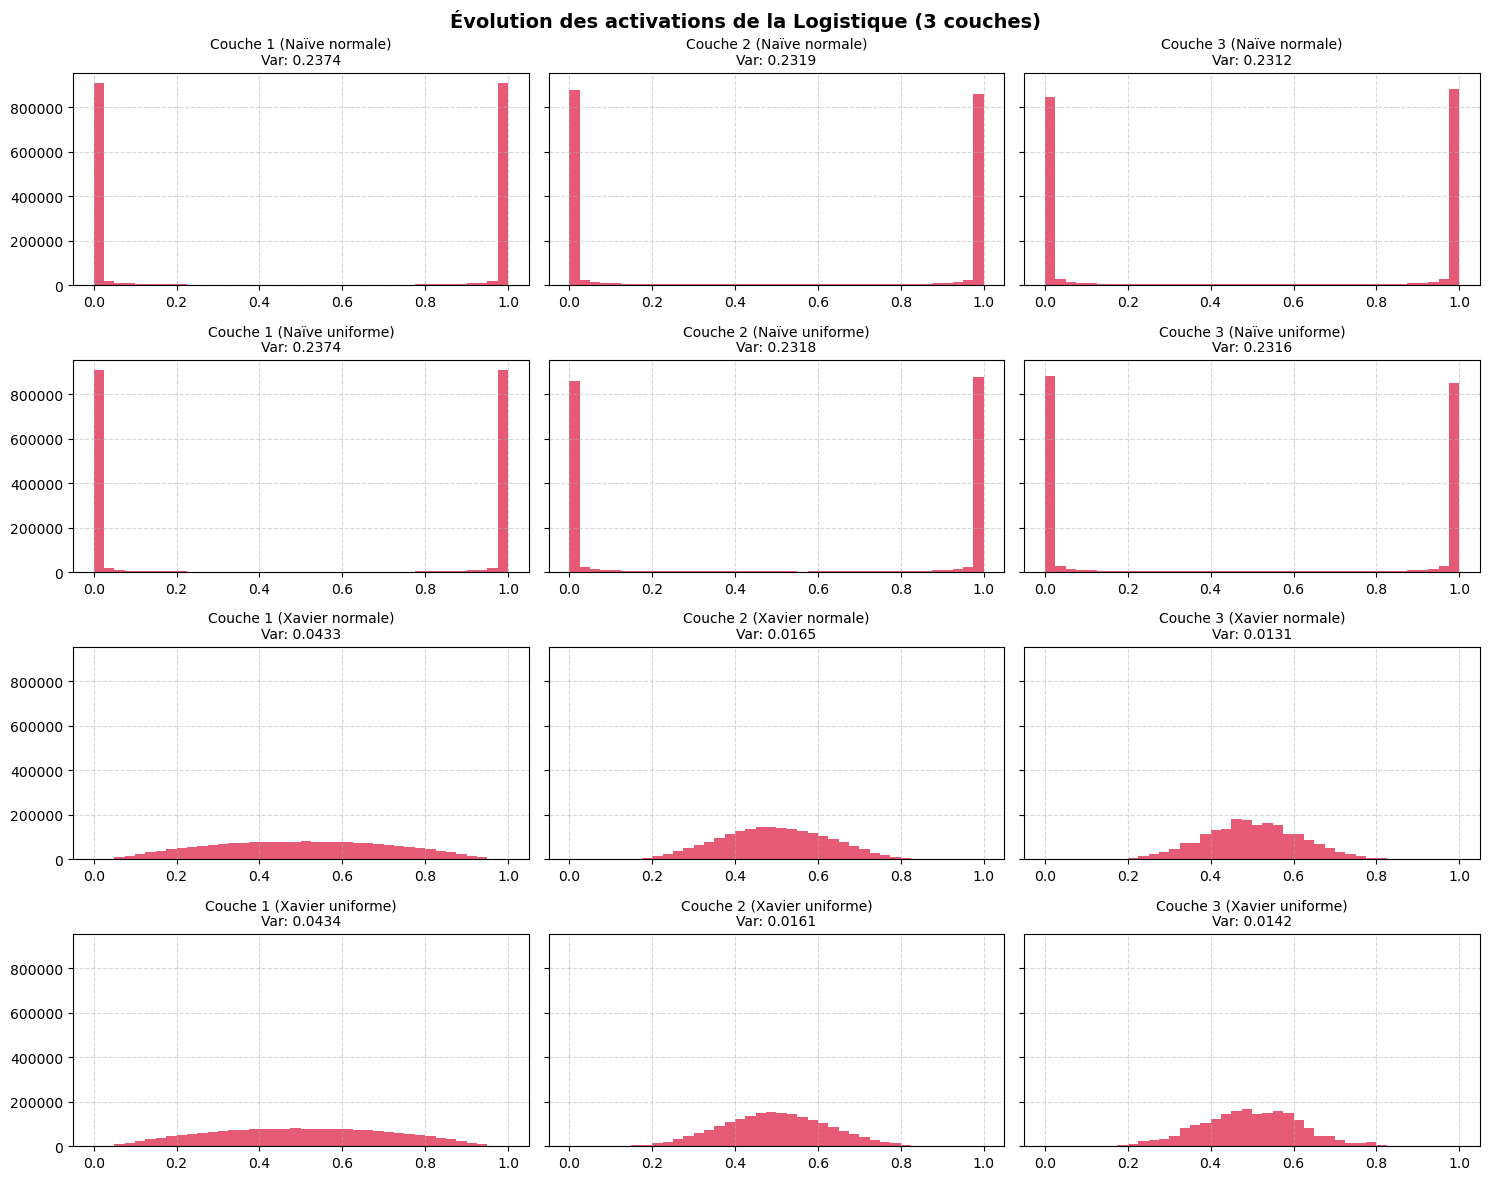

In [22]:
# --- Simulation 2 : Tanh avec Initialisation Naïve vs Xavier ---
activation = "logistic"
activations_naive_normal = simulate_forward(init_mode="naive_normal", activation=activation)
activations_naive_uniform = simulate_forward(init_mode="naive_uniform", activation=activation)
activations_better_normal = simulate_forward(init_mode="xavier_normal", activation=activation)
activations_better_uniform = simulate_forward(init_mode="xavier_uniform", activation=activation)

fig, axes = plt.subplots(4, num_layers, figsize=(15, 12), sharey=True)
fig.suptitle("Évolution des activations de la Logistique (3 couches)", fontsize=14, fontweight='bold')

for i in range(num_layers):
    # Ligne 1 : Init Naïve normale
    axes[0, i].hist(activations_naive_normal[i+1].flatten(), bins=40, range=(0, 1), color='crimson', alpha=0.7)
    axes[0, i].set_title(f"Couche {i+1} (Naïve normale)\nVar: {np.var(activations_naive_normal[i+1]):.4f}", fontsize=10)
    axes[0, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 2 : Init Naïve uniforme
    axes[1, i].hist(activations_naive_uniform[i+1].flatten(), bins=40, range=(0, 1), color='crimson', alpha=0.7)
    axes[1, i].set_title(f"Couche {i+1} (Naïve uniforme)\nVar: {np.var(activations_naive_uniform[i+1]):.4f}", fontsize=10)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 3 : Init 'meilleure' normale
    axes[2, i].hist(activations_better_normal[i+1].flatten(), bins=40, range=(0, 1), color='crimson', alpha=0.7)
    axes[2, i].set_title(f"Couche {i+1} (Xavier normale)\nVar: {np.var(activations_better_normal[i+1]):.4f}", fontsize=10)
    axes[2, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 4 : Init 'meilleure' uniforme
    axes[3, i].hist(activations_better_uniform[i+1].flatten(), bins=40, range=(0, 1), color='crimson', alpha=0.7)
    axes[3, i].set_title(f"Couche {i+1} (Xavier uniforme)\nVar: {np.var(activations_better_uniform[i+1]):.4f}", fontsize=10)
    axes[3, i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

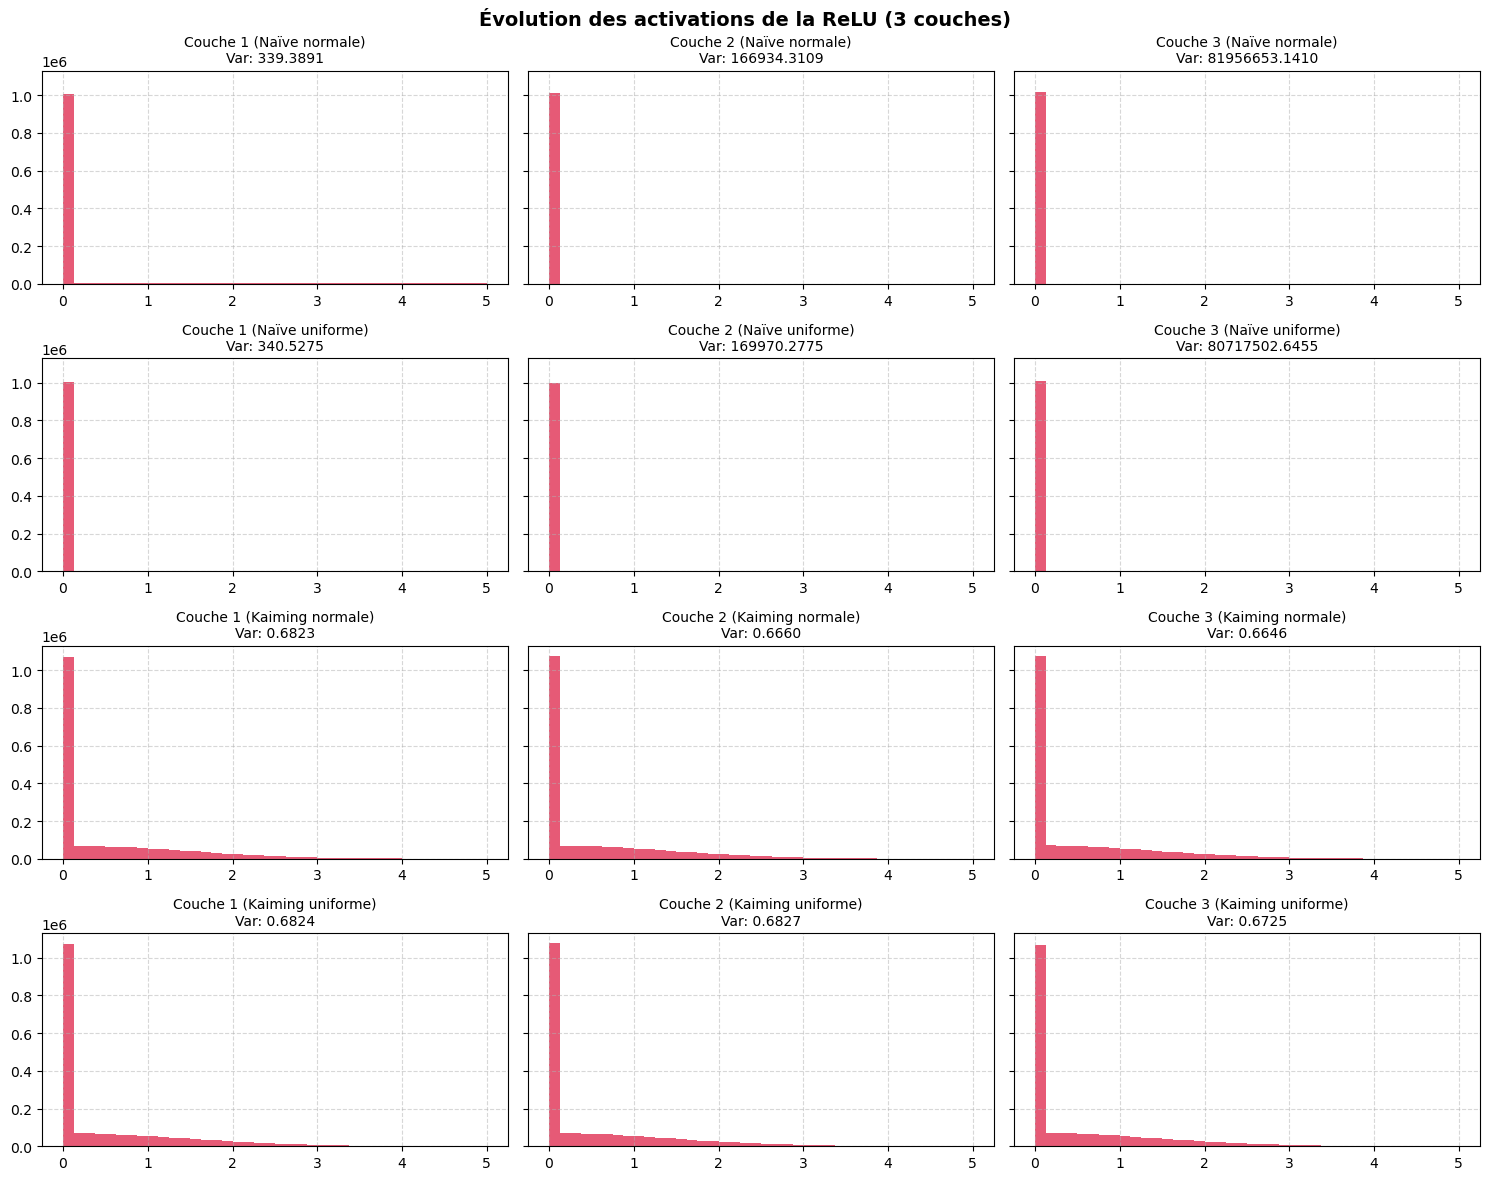

In [23]:
# --- Simulation 3 : Tanh avec Initialisation Naïve vs Kaiming ---
activation = "relu"
activations_naive_normal = simulate_forward(init_mode="naive_normal", activation=activation)
activations_naive_uniform = simulate_forward(init_mode="naive_uniform", activation=activation)
activations_better_normal = simulate_forward(init_mode="kaiming_normal", activation=activation)
activations_better_uniform = simulate_forward(init_mode="kaiming_uniform", activation=activation)

fig, axes = plt.subplots(4, num_layers, figsize=(15, 12), sharey=True)
fig.suptitle("Évolution des activations de la ReLU (3 couches)", fontsize=14, fontweight='bold')

for i in range(num_layers):
    # Ligne 1 : Init Naïve normale
    axes[0, i].hist(activations_naive_normal[i+1].flatten(), bins=40, range=(0, 5), color='crimson', alpha=0.7)
    axes[0, i].set_title(f"Couche {i+1} (Naïve normale)\nVar: {np.var(activations_naive_normal[i+1]):.4f}", fontsize=10)
    axes[0, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 2 : Init Naïve uniforme
    axes[1, i].hist(activations_naive_uniform[i+1].flatten(), bins=40, range=(0, 5), color='crimson', alpha=0.7)
    axes[1, i].set_title(f"Couche {i+1} (Naïve uniforme)\nVar: {np.var(activations_naive_uniform[i+1]):.4f}", fontsize=10)
    axes[1, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 3 : Init 'meilleure' normale
    axes[2, i].hist(activations_better_normal[i+1].flatten(), bins=40, range=(0, 5), color='crimson', alpha=0.7)
    axes[2, i].set_title(f"Couche {i+1} (Kaiming normale)\nVar: {np.var(activations_better_normal[i+1]):.4f}", fontsize=10)
    axes[2, i].grid(True, linestyle='--', alpha=0.5)

    # Ligne 4 : Init 'meilleure' uniforme
    axes[3, i].hist(activations_better_uniform[i+1].flatten(), bins=40, range=(0, 5), color='crimson', alpha=0.7)
    axes[3, i].set_title(f"Couche {i+1} (Kaiming uniforme)\nVar: {np.var(activations_better_uniform[i+1]):.4f}", fontsize=10)
    axes[3, i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()